# Bài 1: Titanic Dataset
## Sử dụng lại bộ dữ liệu Titanic trong bài tập về nhà trước.

## Yêu cầu
Sử dụng Logistic Regression để dự đoán hành khách sống sót hay không.
Sử dụng cùng cách chia dữ liệu train/test như bài tập trước nếu có thể.
Đánh giá kết quả của mô hình Logistic Regression.
So sánh kết quả của Logistic Regression với kết quả của Linear Regression trong bài tập trước.

## Nội dung so sánh
Có thể so sánh dựa trên các chỉ số:
Accuracy
Precision
Recall
F1-score
Confusion Matrix

## Đưa ra nhận xét về mô hình phù hợp hơn đối với bài toán phân loại hành khách sống sót.

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


In [94]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Chuẩn bị dữ liệu.
Lựa chọn biến đầu vào (features) và biến cần dự đoán (target).

In [95]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
X = df[features] # ma trận dữ liệu
y = df["survived"] # nhãn

## Chia tập Train/ Test.

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Chia dữ liệu số và dữ liệu phân loại.
Mỗi kiểu dữ liệu cần xử lý khác nhau.

In [97]:
# Tiền xử lý dữ liệu
numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "pclass"
] # dữ liệu có giá trị số
categorical_features = [
    "sex",
    "embarked"
] # dữ liệu dạng chữ
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # thay giá trị thiếu thành Median
    ("scaler", StandardScaler()) # chuẩn hóa dữ liệu cho cùng thang đo
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # thay giá trị thiếu thành giá trị xuất hiện nhiều nhất
    ("onehot", OneHotEncoder(handle_unknown="ignore")), # chuyển thành tệp số 0 và 1
])
preprocessor = ColumnTransformer([ # áp dụng tiền xử lý cho từng nhóm đặc trưng khác nhau, sau đó kết hợp thành dữ liệu hoàn chỉnh
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Pipeline làm theo trình tự:
- Dữ liệu.
- Điền giá trị thiếu.
- Chuẩn hóa.
- Hoàn thành.

## Xây dựng Logistic Regression.

In [98]:
# Mô hình Logistic Regression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
logistic_model.fit(X_train, y_train) 
# mô hình sẽ học những mối quan hệ với survived để tìm ra các hệ số tối ưu.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

Pipeline làm theo trình tự:
- Dữ liệu.
- Tiền xử lý.
- Logistic Regression.
- Dự đoán.
Mô hình Logistic Regression giúp dự đoán khả năng sống sót.

In [99]:
# Dự đoán
y_pred = logistic_model.predict(X_test)

In [100]:
# Đánh giá mô hình
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1_score:", f1)
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1_score: 0.7244094488188977
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



Các chỉ số Accuracy, Precision, Recall và F1_score cho thấy mô hình ở nhiều góc độ khác nhau. Nhưng F1_score thường được quan tâm vì cân bằng giữa Precision và Recall.

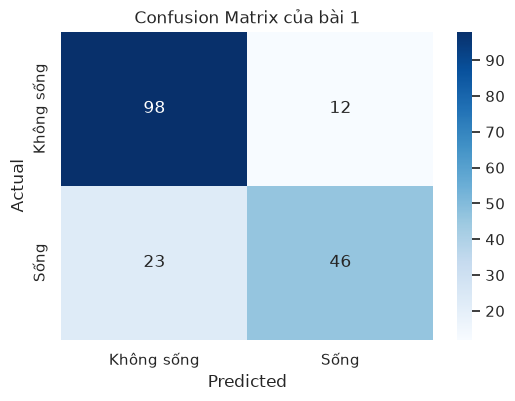

In [101]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Không sống", "Sống"],
    yticklabels=["Không sống", "Sống"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix của bài 1")
plt.show()

## Nhận xét biểu đồ:
Có (96 + 47)/179 = 143/179 = 79.9% mẫu mô hình đã dự đoán đúng tương ứng với Accuracy, cho thấy khả năng phân loại của nó khá tốt. Nhưng độ nhận diện hành khách không sống sót (96) tốt hơn hành khách sống sót (47). Nhìn chung, mô hình phân loại khá chính xác trên tệp dữ liệu này.

In [102]:
# So sánh với Linear Regression
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
linear_model.fit(X_train, y_train)

# Dự đoán
y_pred_linear = linear_model.predict(X_test)

# Chuyển về 0 hoặc 1
y_pred_linear = (y_pred_linear >= 0.5).astype(int)
acc_linear = accuracy_score(y_test, y_pred_linear)
pre_linear = precision_score(y_test, y_pred_linear)
rec_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1_score"],
    "Linear Regression": [
        acc_linear,
        pre_linear,
        rec_linear,
        f1_linear
    ],
    "Logistic Regression": [
        acc,
        pre,
        rec,
        f1
    ]
})
comparison

,Metric,Linear Regression,Logistic Regression
0,Accuracy,0.810056,0.804469
1,Precision,0.786885,0.793103
2,Recall,0.695652,0.666667
3,F1_score,0.738462,0.724409


## So sánh 2 mô hình Logistic Regression và Linear Regression.
Logistic Regression thường có các chỉ số cao hơn hẳn so với Linear Regression. Logistic Regression dự đoán xác suất bằng hàm Sigmoid, phù hợp với bài toán phân loại nhị phân; còn Linear Regression dự đoán giá trị liên tục nên phải chuyển thành 0 hoặc 1 bằng 1 ngưỡng khác, dẫn đến hiệu quả thấp hơn. 
=> Đối với bộ dữ liệu Titanic này, Logistic Regression phù hợp hơn để dự đoán khả năng sống sót của hành khách trên tàu.

# Bài 2: Dry Bean Dataset
## Xây dựng mô hình phân loại các loại hạt trong bộ dữ liệu Dry Bean Dataset bằng hai thuật toán:

Logistic Regression
K-Nearest Neighbors – KNN
## Dữ liệu
Dữ liệu đã được preprocessing (file processing_seeds.ipynb) và chia thành hai tập:

Dry_Bean_Dataset/
├── dry_bean_train.csv
└── dry_bean_test.csv

## Các bạn có thể tự tạo file processing để có thể processing theo ý mình

In [103]:
from sklearn.neighbors import KNeighborsClassifier

train_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_train.csv")
test_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_test.csv")
print("Dữ liệu của train", train_df.shape)
print("Dữ liệu của test:", test_df.shape)
train_df.head()

Dữ liệu của train (10834, 17)
Dữ liệu của test: (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


In [105]:
# X chứa các đặc trưng.
# y là loại hạt cần dự đoán.
X_train = train_df.drop("class", axis=1)
y_train = train_df["class"]
X_test = test_df.drop("class", axis=1)
y_test = test_df["class"]
print(X_train.shape)
print(X_test.shape)

(10834, 16)
(2709, 16)


## Huấn luyện Logistic Regression.

In [106]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train, y_train)

# Dự đoán.
y_pred_log = log_model.predict(X_test)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Đánh giá Logistic Regression.

In [107]:
acc = accuracy_score(y_test, y_pred_log)
pre = precision_score(y_test, y_pred_log, average="weighted")
rec = recall_score(y_test, y_pred_log, average="weighted")
f1 = f1_score(y_test, y_pred_log, average="weighted")
print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1_score:", f1)
print(classification_report(y_test, y_pred_log))
# bài toán đa lớp nên phải tính trung bình có trọng số giữa các lớp.

Accuracy: 0.8545588778146918
Precision: 0.8561185483948659
Recall: 0.8545588778146918
F1_score: 0.8546241383441154
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.79      0.84       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.87      0.91      0.89       326
    DERMASON       0.87      0.88      0.87       709
       HOROZ       0.87      0.88      0.87       372
       SEKER       0.86      0.80      0.83       406
        SIRA       0.77      0.82      0.79       527

    accuracy                           0.85      2709
   macro avg       0.88      0.87      0.87      2709
weighted avg       0.86      0.85      0.85      2709



## Biểu đồ thể hiện Confusion Matrix của Logistic.

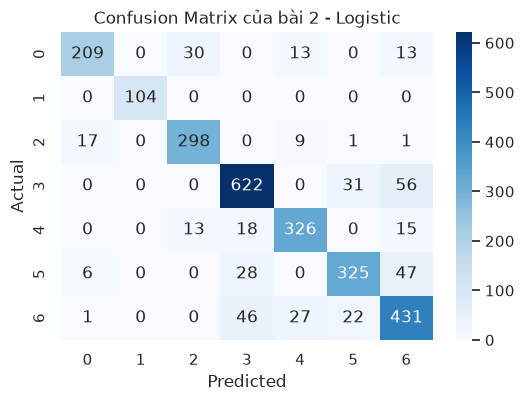

In [108]:
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix của bài 2 - Logistic")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Mô hình đạt độ chính xác khá cao, ma trận nhầm lẫn cho thấy phần lớn mẫu được dự đoán là đúng, chỉ có thiểu số bị nhầm giữa các lớp có đặc điểm tương tự.

## Huấn luyện KNN.

In [109]:
knn = KNeighborsClassifier(
    n_neighbors=5 # một hạt đậu mới sẽ được phân theo 5 hạt đậu gần nhất.
)
knn.fit(X_train, y_train)

# Dự đoán.
y_pred_knn = knn.predict(X_test)

## Đánh giá KNN.

In [110]:
acc = accuracy_score(y_test, y_pred_knn)
pre = precision_score(y_test, y_pred_knn, average="weighted")
rec = recall_score(y_test, y_pred_knn, average="weighted")
f1 = f1_score(y_test, y_pred_knn, average="weighted")
print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1_score:", f1)
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7305278700627538
Precision: 0.7302432287862707
Recall: 0.7305278700627538
F1_score: 0.7278216266009703
              precision    recall  f1-score   support

    BARBUNYA       0.52      0.50      0.51       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.65      0.66      0.65       326
    DERMASON       0.81      0.90      0.85       709
       HOROZ       0.73      0.69      0.71       372
       SEKER       0.79      0.61      0.69       406
        SIRA       0.68      0.73      0.71       527

    accuracy                           0.73      2709
   macro avg       0.74      0.73      0.73      2709
weighted avg       0.73      0.73      0.73      2709



## Biểu đồ thể hiện Confusion Matrix của KNN.

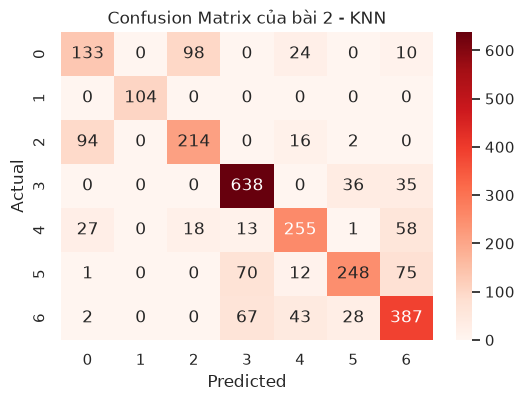

In [111]:
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)
plt.title("Confusion Matrix của bài 2 - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Mô hình phân loại dựa trên các mẫu lân cận gần nhất. Nếu dữ liệu được chuẩn hóa trong tiền xử lý, KNN cho độ chính xác cao, do khoảng cách giữa các điểm dữ liệu phản ánh đúng mức độ tương đồng giữa các mẫu.

## So sánh 2 mô hình (thêm cho biết).

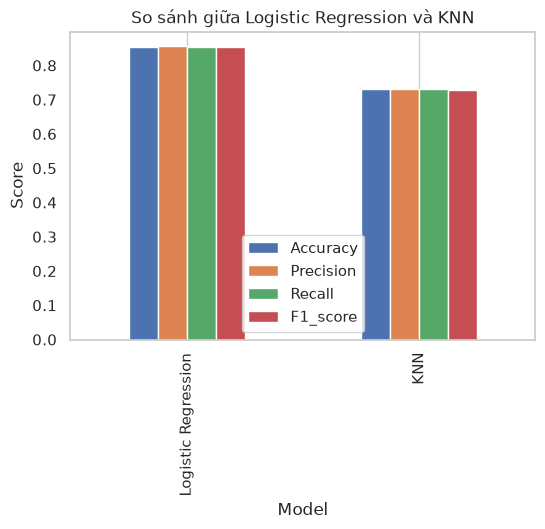

In [112]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, average="weighted"),
        precision_score(y_test, y_pred_knn, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, average="weighted"),
        recall_score(y_test, y_pred_knn, average="weighted")
    ],
    "F1_score": [
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_knn, average="weighted")
    ]
})
comparison
# Vẽ biểu đồ so sánh.
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(6,4)
)
plt.title("So sánh giữa Logistic Regression và KNN")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()

Logistic Regression có mô hình đơn giản và quy trình huấn luyện nhẹ nhàng, nhanh.
KNN có các chỉ số cao hơn, đặc biệt ở Accuracy và F1_score cao hơn hẳn nên rất phù hợp với dữ liệu do khai thác tốt cấu trúc gần nhất của các mẫu. 
=> Tùy bài toán sẽ phù hợp với mô hình nào.